MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
Simple Linear Regression Results:
MSE: 0.7091157771765548
RMSE: 0.8420901241414454
R² Score: 0.45885918903846656


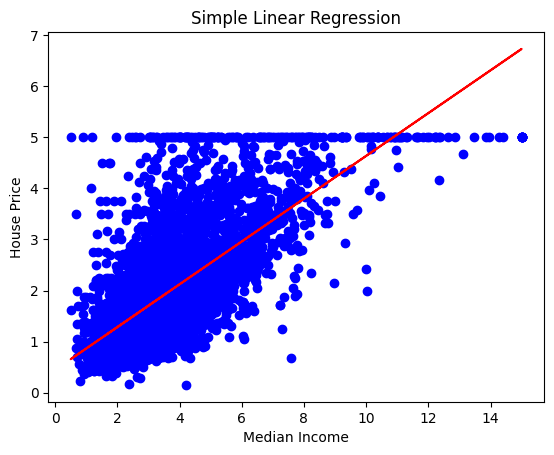

Multiple Linear Regression Results:
MSE: 0.5558915986952444
RMSE: 0.7455813830127764
R² Score: 0.5757877060324508


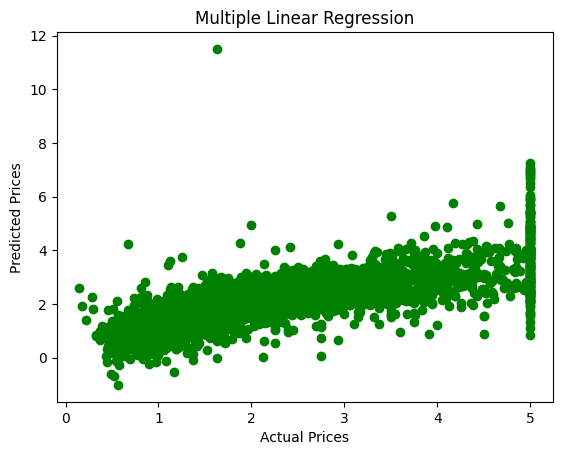

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

data = fetch_california_housing(as_frame=True)
df = data.frame

df.head()

print(df.isnull().sum())

scaler = StandardScaler()

#simple linear regression
X_simple = df[['MedInc']]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

slr = LinearRegression()
slr.fit(X_train_scaled, y_train)

y_pred_simple = slr.predict(X_test_scaled)

mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression Results:")
print("MSE:", mse_simple)
print("RMSE:", rmse_simple)
print("R² Score:", r2_simple)

plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred_simple, color='red')
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.show()

#Multiple Linear Regression
X_multi = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)

y_pred_multi = mlr.predict(X_test_scaled)

mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("Multiple Linear Regression Results:")
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R² Score:", r2_multi)

plt.scatter(y_test, y_pred_multi, color='green')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Multiple Linear Regression")
plt.show()